# Deskriptive Analyse — Qualitäts-Muster-Finder

**Basis:** `analysetabelle.csv` (1.821 Krankenhäuser, 18 Spalten)  
**Ziel:** 12 aussagekräftige Grafiken + je ein Befundsatz

Struktur:
1. Setup & Daten laden
2. Einzelne Merkmale (univariat)
3. Gruppenvergleiche: MIT vs. OHNE viele Probleme
4. Korrelationen & Zusammenhänge
5. Störfaktoren aufspüren
6. Befunde zusammenfassen


### 1 Setup
Bibliotheken laden (`pandas`, `numpy`, `matplotlib`, `seaborn`), einheitliches Farbschema festlegen (🟢 grün = wenige Probleme, 🔴 rot = viele Probleme), `analysetabelle.csv` einlesen und Koordinatenspalten von Komma- auf Punkt-Dezimalschreibweise umstellen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# Einheitliches Design
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

FARBEN = {0: "#2ecc71", 1: "#e74c3c"}   # grün = wenig Probleme, rot = viele
LABELS  = {0: "Wenige Probleme", 1: "Viele Probleme"}

df = pd.read_csv("../Data/analysetabelle.csv", low_memory=False)

# Latitude/Longitude: Komma → Punkt
for col in ["SO.Latitude", "SO.Longitude"]:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False).pipe(pd.to_numeric, errors="coerce")

print(f"Datensatz: {df.shape}")
print(f"Ziel-Variable: {df['hat_viele_Probleme'].value_counts().to_dict()}")
df.head(3)

Datensatz: (1821, 18)
Ziel-Variable: {0: 916, 1: 905}


,SO.QBID,total_qi,auffaellig_n,auffaellig_quote,hat_viele_Probleme,SO.Name,SO.Betten,SO.Bundesland,SO.Uni,KH.Träger,KH.Träger.Art,SO.Latitude,SO.Longitude,SO.Standortnummer,fortbildungsquote,aerzte_pro_bett,pflege_pro_bett,ist_konzern
0,4876,19,1,0.052632,0,Park-Klinik GmbH,39,Schleswig-Holstein,0,Park-Klinik GmbH,privat,54.326732,10.125615,773063000,1.0,0.358974,2.415128,0
1,4878,2,0,0.000000,0,Johanniter Tagesklinik Schwarzenbek,0,Schleswig-Holstein,0,Johanniter-Krankenhaus Geesthacht GmbH,freigemeinnützig,53.505720,10.478568,772344000,1.0,NaN,NaN,0
2,4879,18,1,0.055556,0,Sankt Elisabeth Krankenhaus Kiel,43,Schleswig-Holstein,0,Lubinus-Kliniken GmbH,freigemeinnützig,54.316855,10.127381,771993000,1.0,0.800000,0.828372,0


---
## 2 Einzelne Merkmale untersuchen (univariat)

**Was heißt "univariat"?** Der Begriff kommt aus dem Lateinischen (*unus* = eins, *varia* = veränderlich) und bezeichnet die Betrachtung **eines einzelnen Merkmals für sich allein** — ohne es mit einem anderen Merkmal in Beziehung zu setzen. Das Gegenstück ist die **bivariate** Analyse (zwei Merkmale gleichzeitig, z. B. ein Streudiagramm) bzw. die **multivariate** Analyse (mehrere Merkmale gleichzeitig, wie später beim Decision Tree in `03_Decision_Tree.ipynb`).

**Warum univariat zuerst?** Bevor man prüft, ob zwei Merkmale zusammenhängen (Kapitel 4), muss man jedes Merkmal erst für sich verstehen: Wie ist es verteilt? Gibt es Ausreißer oder fehlende Werte? Unterscheiden sich die beiden Gruppen (wenige vs. viele Probleme) überhaupt sichtbar? Ohne diesen Schritt würde man möglicherweise Tests auf Merkmale anwenden, die offensichtlich nichts hergeben, oder Ausreißer übersehen, die das Ergebnis später verzerren.

In diesem Abschnitt entstehen die Grafiken 1–7 sowie 11–12 — je eine Grafik pro Merkmal, verglichen zwischen den beiden Gruppen `hat_viele_Probleme = 0` (wenige Probleme) und `= 1` (viele Probleme).

### Grafik 1 — Verteilung der auffällig-Quote
Histogramm der `auffaellig_quote` über alle 1.821 Häuser. Balken links vom Median blau, rechts orange. Medianline als gestrichelte graue Linie. Zeigt, wie die Ziel-Variable selbst verteilt ist — Grundlage für alle weiteren Gruppenvergleiche.

In [2]:
# ── Grafik 1: Verteilung der auffällig-Quote (interaktiv, mit Hover) ────
median = df["auffaellig_quote"].median()

# Bins einmal berechnen, dann die zwei Farbgruppen mit denselben Bins zeichnen
counts_all, bin_edges = np.histogram(df["auffaellig_quote"].dropna(), bins=30)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Hover-Text je Balken: Bereich (von–bis) + Anzahl Häuser
hover_text = [
    f"{links:.1%} – {rechts:.1%}<br>{n} Häuser"
    for links, rechts, n in zip(bin_edges[:-1], bin_edges[1:], counts_all)
]

# Blau = vor Median, Orange = nach Median — als zwei Traces für Farbe + Legende
vor_median  = bin_centers <= median
nach_median = ~vor_median

fig = go.Figure()
fig.add_trace(go.Bar(
    x=bin_centers[vor_median], y=counts_all[vor_median],
    width=bin_width * 0.92, marker_color="#3498db",
    name=f"Vor Median (≤ {median:.0%})",
    hovertext=[t for t, m in zip(hover_text, vor_median) if m], hoverinfo="text",
))
fig.add_trace(go.Bar(
    x=bin_centers[nach_median], y=counts_all[nach_median],
    width=bin_width * 0.92, marker_color="#e67e22",
    name=f"Nach Median (> {median:.0%})",
    hovertext=[t for t, m in zip(hover_text, nach_median) if m], hoverinfo="text",
))
fig.add_trace(go.Scatter(
    x=bin_centers, y=counts_all, mode="lines+markers",
    line=dict(color="#2c3e50", width=1.5), marker=dict(size=4),
    name="Verlauf der Balkenhöhen", hoverinfo="skip",
))
fig.add_vline(x=median, line_dash="dash", line_color="gray",
              annotation_text=f"Median = {median:.0%}", annotation_position="top")

fig.update_layout(
    title="Grafik 1: Verteilung der auffällig-Quote",
    xaxis_title="Anteil auffälliger Qualitätsindikatoren",
    yaxis_title="Anzahl Krankenhäuser",
    xaxis=dict(tickformat=".0%", dtick=0.1),
    bargap=0, width=1000, height=550,
    template="plotly_white",
)
fig.show()

q1_hist = df["auffaellig_quote"].quantile(0.25)
q3_hist = df["auffaellig_quote"].quantile(0.75)
anteil_null = (df["auffaellig_quote"] == 0).mean()

print("\n📌 Befund: Die auffällig-Quote ist rechtsschief verteilt — "
      "die meisten Häuser liegen zwischen {:.0%} und {:.0%} (Q1–Q3), "
      "rund {:.0%} der Häuser haben sogar 0% auffällige Indikatoren. "
      "Der Median liegt bei {:.0%}. Nur ein dünner Ausläufer reicht bis 100%. "
      "Zum Ablesen genauer Werte: Maus über die Balken bewegen.".format(q1_hist, q3_hist, anteil_null, median))


📌 Befund: Die auffällig-Quote ist rechtsschief verteilt — die meisten Häuser liegen zwischen 0% und 11% (Q1–Q3), rund 28% der Häuser haben sogar 0% auffällige Indikatoren. Der Median liegt bei 6%. Nur ein dünner Ausläufer reicht bis 100%. Zum Ablesen genauer Werte: Maus über die Balken bewegen.


### 📊 Grafik 2 — Bettenzahl
Links: Histogramm der Bettenzahl (gekappt bei 1.500, damit einzelne Großkliniken die Skala nicht verzerren). Rechts: Boxplot der Bettenzahl getrennt nach Gruppe (wenige/viele Probleme) — zeigt, ob Hausgröße mit Qualitätsproblemen zusammenhängt.

In [3]:
# ── Grafik 2: Bettenzahl (interaktiv, mit Hover) ─────────────────

# Histogramm-Bins berechnen (gekappt bei 1.500, wie bisher — sonst wuerden 11 Grosskliniken
# die Skala verzerren, siehe Doku/MD/02_Analyse.md)
betten_capped = df["SO.Betten"].clip(upper=1500)
counts_hist, bin_edges_hist = np.histogram(betten_capped, bins=40)
bin_centers_hist = (bin_edges_hist[:-1] + bin_edges_hist[1:]) / 2
bin_width_hist = bin_edges_hist[1] - bin_edges_hist[0]

# Hover-Text je Balken: Bereich (von–bis) + Anzahl Häuser
hover_hist = [
    f"{links:.0f} – {rechts:.0f} Betten<br>{n} Häuser"
    for links, rechts, n in zip(bin_edges_hist[:-1], bin_edges_hist[1:], counts_hist)
]

fig = make_subplots(
    rows=2, cols=1, vertical_spacing=0.14,
    subplot_titles=("Verteilung Bettenzahl", "Bettenzahl: MIT vs. OHNE viele Probleme"),
)

fig.add_trace(go.Bar(
    x=bin_centers_hist, y=counts_hist, width=bin_width_hist * 0.92,
    marker_color="#9b59b6", name="Bettenzahl", showlegend=False,
    hovertext=hover_hist, hoverinfo="text",
), row=1, col=1)

# Boxplot nach Ziel-Variable — bewusst NICHT gekappt (anders als das Histogramm oben),
# damit auch die Ausreißer bis ca. 3.000 Betten sichtbar bleiben
for g in [0, 1]:
    fig.add_trace(go.Box(
        y=df[df["hat_viele_Probleme"] == g]["SO.Betten"],
        name=LABELS[g], marker_color=FARBEN[g], boxpoints="outliers", showlegend=False,
    ), row=2, col=1)

fig.update_xaxes(title_text="Bettenzahl (gekappt bei 1.500)", row=1, col=1)
fig.update_yaxes(title_text="Anzahl Krankenhäuser", row=1, col=1)
fig.update_yaxes(title_text="Bettenzahl", row=2, col=1)

fig.update_layout(
    title="Grafik 2: Bettenzahl",
    width=800, height=850,
    template="plotly_white",
)
fig.show()

m0 = df[df["hat_viele_Probleme"]==0]["SO.Betten"].median()
m1 = df[df["hat_viele_Probleme"]==1]["SO.Betten"].median()

# Statistische Einordnung: ist der Median-Unterschied real, und wie stark?
from scipy import stats as _stats
_g0 = df[df["hat_viele_Probleme"]==0]["SO.Betten"].dropna()
_g1 = df[df["hat_viele_Probleme"]==1]["SO.Betten"].dropna()
_t, _p = _stats.ttest_ind(_g0, _g1)
_r = df[["SO.Betten","hat_viele_Probleme"]].corr().iloc[0,1]

print(f"\n📌 Befund: Median Betten — Wenige Probleme: {m0:.0f}, Viele Probleme: {m1:.0f} "
      f"({(m0-m1)/m0:.1%} weniger). Statistisch signifikant (T-Test: t={_t:.2f}, p={_p:.4f}), aber "
      f"schwacher Zusammenhang (r={_r:.2f}) — bei dieser Stichprobengröße (n={len(_g0)}+{len(_g1)}) "
      f"werden schon kleine Effekte statistisch signifikant. Die Wertebereiche beider Gruppen "
      f"überlappen stark, Bettenzahl allein hat kaum Vorhersagekraft. Zum Ablesen genauer Werte: "
      f"Maus über Balken/Boxplot bewegen.")


📌 Befund: Median Betten — Wenige Probleme: 166, Viele Probleme: 220 (-32.5% weniger). Statistisch signifikant (T-Test: t=-5.93, p=0.0000), aber schwacher Zusammenhang (r=0.14) — bei dieser Stichprobengröße (n=916+905) werden schon kleine Effekte statistisch signifikant. Die Wertebereiche beider Gruppen überlappen stark, Bettenzahl allein hat kaum Vorhersagekraft. Zum Ablesen genauer Werte: Maus über Balken/Boxplot bewegen.


### Grafik 3 — Trägerschaft
Gruppiertes Balkendiagramm: Anteil „Wenige Probleme" vs. „Viele Probleme" je Trägerart (privat / freigemeinnützig / öffentlich). Zeigt, ob die Trägerschaft mit der Auffälligkeitsquote zusammenhängt.

In [4]:
# ── Grafik 3: Trägerschaft (interaktiv, mit Hover) ───────────────
traeger_counts = (
    df.groupby(["KH.Träger.Art", "hat_viele_Probleme"])
    .size().reset_index(name="n")
)
traeger_pct = traeger_counts.copy()
total = traeger_counts.groupby("KH.Träger.Art")["n"].transform("sum")
traeger_pct["pct"] = traeger_counts["n"] / total * 100

pivot_pct = traeger_pct.pivot(index="KH.Träger.Art", columns="hat_viele_Probleme", values="pct")
pivot_n   = traeger_counts.pivot(index="KH.Träger.Art", columns="hat_viele_Probleme", values="n")

fig = go.Figure()
for g in [0, 1]:
    hover_traeger = [
        f"{traeger}<br>{LABELS[g]}: {pct:.1f}%<br>n={n} Häuser"
        for traeger, pct, n in zip(pivot_pct.index, pivot_pct[g], pivot_n[g])
    ]
    fig.add_trace(go.Bar(
        x=pivot_pct.index, y=pivot_pct[g],
        name=LABELS[g], marker_color=FARBEN[g],
        hovertext=hover_traeger, hoverinfo="text",
    ))

fig.update_layout(
    title="Grafik 3: Anteil 'Viele Probleme' nach Trägerschaft",
    xaxis_title="Trägerschaft", yaxis_title="Anteil (%)",
    yaxis_range=[0, 70],
    barmode="group", template="plotly_white",
    width=850, height=580,
)
fig.show()

for traeger in df["KH.Träger.Art"].dropna().unique():
    sub = df[df["KH.Träger.Art"]==traeger]
    pct = sub["hat_viele_Probleme"].mean()
    print(f"  {traeger:20s}: {pct:.1%} haben viele Probleme  (n={len(sub)})")
print("\n📌 Befund: Prüfen ob sich Trägerarten systematisch unterscheiden. Zum Ablesen genauer Werte: Maus über die Balken bewegen.")

  privat              : 43.8% haben viele Probleme  (n=502)
  freigemeinnützig    : 50.6% haben viele Probleme  (n=607)
  öffentlich          : 53.5% haben viele Probleme  (n=684)

📌 Befund: Prüfen ob sich Trägerarten systematisch unterscheiden. Zum Ablesen genauer Werte: Maus über die Balken bewegen.


### Grafik 4 — Uni-Kliniken vs. normale Häuser
Balkendiagramm: Anteil „Viele Probleme" für Uni-Kliniken vs. normale Häuser. Prüft die Hypothese, dass akademische Kliniken durch intensivere Forschung und Facharztdichte besser abschneiden.

In [5]:
# ── Grafik 4: Uni-Kliniken vs. normale Häuser (interaktiv, mit Hover) ────
uni_pct = (
    df.groupby("SO.Uni")["hat_viele_Probleme"].mean() * 100
).rename({0: "Normale Häuser", 1: "Uni-Kliniken"})
uni_n = df.groupby("SO.Uni").size().rename({0: "Normale Häuser", 1: "Uni-Kliniken"})

hover_uni = [
    f"{name}<br>{val:.1f}% haben viele Probleme<br>n={uni_n[name]} Häuser"
    for name, val in uni_pct.items()
]

fig = go.Figure(go.Bar(
    x=list(uni_pct.index), y=uni_pct.values,
    marker_color=["#3498db", "#e67e22"],
    hovertext=hover_uni, hoverinfo="text",
))
fig.update_layout(
    title="Grafik 4: Uni-Kliniken vs. normale Häuser",
    yaxis_title="Anteil 'Viele Probleme' (%)",
    yaxis_range=[0, 100],
    template="plotly_white",
    width=750, height=620,
)
fig.show()

n_uni   = df[df["SO.Uni"]==1]
n_norm  = df[df["SO.Uni"]==0]
print(f"  Uni-Kliniken:    {n_uni['hat_viele_Probleme'].mean():.1%} haben viele Probleme (n={len(n_uni)})")
print(f"  Normale Häuser:  {n_norm['hat_viele_Probleme'].mean():.1%} haben viele Probleme (n={len(n_norm)})")
print("\n📌 Befund: Vergleich Uni- vs. Nicht-Uni-Kliniken hinsichtlich Qualitätsproblemen. Zum Ablesen genauer Werte: Maus über die Balken bewegen.")

  Uni-Kliniken:    68.5% haben viele Probleme (n=92)
  Normale Häuser:  48.7% haben viele Probleme (n=1729)

📌 Befund: Vergleich Uni- vs. Nicht-Uni-Kliniken hinsichtlich Qualitätsproblemen. Zum Ablesen genauer Werte: Maus über die Balken bewegen.


---
## 3 Gruppenvergleiche: Metrische Merkmale MIT vs. OHNE

### 📊 Grafiken 5+6 — Fortbildungsquote & Ärzte pro Bett
Zwei Boxplots nebeneinander: Fortbildungsquote und Ärzte pro Bett, jeweils getrennt nach Gruppe. Zeigt, ob mehr Personal oder höhere Fortbildungsbeteiligung mit weniger Qualitätsproblemen einhergeht. Ausreißer werden ausgeblendet (`showfliers=False`) für bessere Lesbarkeit.

In [6]:
# ── Grafik 5+6: Fortbildungsquote & Ärzte pro Bett (interaktiv, mit Hover) ────
fig = make_subplots(rows=1, cols=2, subplot_titles=("Fortbildungsquote", "Ärzte pro Bett"))

for col_idx, (col, label) in enumerate(zip(
    ["fortbildungsquote", "aerzte_pro_bett"],
    ["Fortbildungsquote", "Ärzte pro Bett"]
), start=1):
    for g in [0, 1]:
        fig.add_trace(go.Box(
            y=df[df["hat_viele_Probleme"] == g][col].dropna(),
            name=LABELS[g], marker_color=FARBEN[g], boxpoints=False,
            legendgroup=LABELS[g], showlegend=(col_idx == 1),
        ), row=1, col=col_idx)
    fig.update_yaxes(title_text=label, row=1, col=col_idx)

fig.update_layout(
    title="Grafik 5+6: Merkmale MIT vs. OHNE viele Probleme",
    template="plotly_white",
    width=900, height=480,
)
fig.show()

for col, label in [("fortbildungsquote", "Fortbildungsquote"), ("aerzte_pro_bett", "Ärzte/Bett")]:
    m0 = df[df["hat_viele_Probleme"]==0][col].median()
    m1 = df[df["hat_viele_Probleme"]==1][col].median()
    print(f"  {label:20s}: Wenige={m0:.3f}, Viele={m1:.3f}")
print("\n📌 Befund: Prüfen ob Fortbildungsquote oder Ärztedichte einen Unterschied zeigen. Zum Ablesen genauer Werte: Maus über die Box bewegen.")

  Fortbildungsquote   : Wenige=0.667, Viele=0.667
  Ärzte/Bett          : Wenige=0.382, Viele=0.470

📌 Befund: Prüfen ob Fortbildungsquote oder Ärztedichte einen Unterschied zeigen. Zum Ablesen genauer Werte: Maus über die Box bewegen.


### Grafik 7 — Anteil Häuser mit vielen Problemen je Bundesland
Horizontales Balkendiagramm, nach Anteil sortiert. Balken rot wenn Anteil > 50 %, grün sonst. Zeigt regionale Unterschiede — kleine Bundesländer (wenige Häuser) müssen wegen hoher Schwankungsbreite vorsichtig interpretiert werden.

**Warum 50 % als Grenze, nicht 5,88 %?** `hat_viele_Probleme` entsteht durch einen Median-Split von `auffaellig_quote` bei 5,88 % — aber dieser Schwellenwert gilt nur für die Quote *innerhalb* eines Hauses. Das daraus resultierende 0/1-Flag hat automatisch einen Mittelwert von ~50 % über alle Häuser (49,7 %), und genau diesen Flag-Mittelwert zeigt Grafik 7 je Bundesland — deshalb 50 %, nicht 5,88 %.

In [7]:
# ── Grafik 7: Bundesland (interaktiv, mit Hover) ─────────────────
bl_pct = (
    df.groupby("SO.Bundesland")["hat_viele_Probleme"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "quote", "count": "n"})
    .sort_values("quote", ascending=True)
)

colors = ["#e74c3c" if q > 0.5 else "#2ecc71" for q in bl_pct["quote"]]
hover_bl = [
    f"{land}<br>{q:.1%} viele Probleme<br>n={n:.0f} Häuser"
    for land, q, n in zip(bl_pct.index, bl_pct["quote"], bl_pct["n"])
]

fig = go.Figure(go.Bar(
    x=bl_pct["quote"] * 100, y=bl_pct.index, orientation="h",
    marker_color=colors,
    hovertext=hover_bl, hoverinfo="text",
))
fig.add_vline(x=50, line_dash="dash", line_color="gray")
fig.update_layout(
    title="Grafik 7: Anteil Häuser mit vielen Problemen je Bundesland",
    xaxis_title="Anteil 'Viele Probleme' (%)",
    template="plotly_white",
    width=800, height=550,
)
fig.show()

top = bl_pct.iloc[-1]
low = bl_pct.iloc[0]
print(f"\n📌 Befund: Höchster Anteil: {top.name} ({top['quote']:.1%}), "
      f"niedrigster: {low.name} ({low['quote']:.1%}). "
      f"Regionale Unterschiede sichtbar? Achtung: kleine n beachten. Zum Ablesen genauer Werte: Maus über die Balken bewegen.")


📌 Befund: Höchster Anteil: Rheinland-Pfalz (64.0%), niedrigster: Thüringen (36.0%). Regionale Unterschiede sichtbar? Achtung: kleine n beachten. Zum Ablesen genauer Werte: Maus über die Balken bewegen.


---
## 4 Korrelationen & Zusammenhänge

### Grafik 8 — Korrelationsmatrix
Heatmap aller Korrelationen (Pearson r) zwischen den numerischen Merkmalen. Zeigt auf einen Blick, welche Merkmale miteinander und mit der Ziel-Variable (`hat_viele_Probleme`) zusammenhängen. Stärkste Zusammenhänge werden anschließend einzeln ausgegeben.

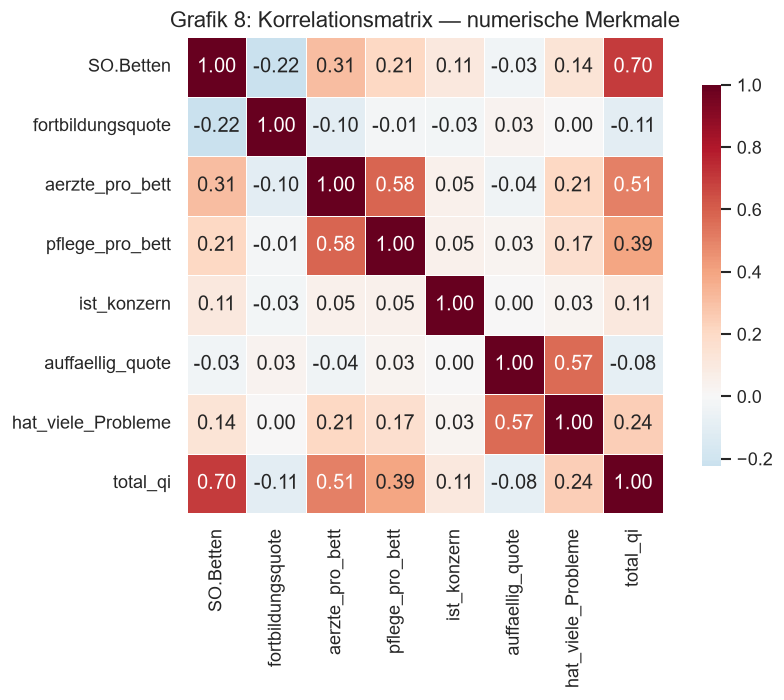


Korrelation mit hat_viele_Probleme (|r|):
  auffaellig_quote         : +0.569
  total_qi                 : +0.241
  aerzte_pro_bett          : +0.210
  pflege_pro_bett          : +0.174
  SO.Betten                : +0.138
  ist_konzern              : +0.028
  fortbildungsquote        : +0.005

📌 Befund: Welches Merkmal korreliert am stärksten mit der Ziel-Variable?


In [8]:
# ── Grafik 8: Korrelations-Heatmap ──────────────────────────────
num_cols = ["SO.Betten", "fortbildungsquote", "aerzte_pro_bett", "pflege_pro_bett",
            "ist_konzern", "auffaellig_quote", "hat_viele_Probleme", "total_qi"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Grafik 8: Korrelationsmatrix — numerische Merkmale")
plt.tight_layout()
plt.show()

# Stärkste Korrelation mit Ziel-Variable
target_corr = corr["hat_viele_Probleme"].drop("hat_viele_Probleme").abs().sort_values(ascending=False)
print("\nKorrelation mit hat_viele_Probleme (|r|):")
for col, val in target_corr.items():
    print(f"  {col:25s}: {corr.loc[col,'hat_viele_Probleme']:+.3f}")
print("\n📌 Befund: Welches Merkmal korreliert am stärksten mit der Ziel-Variable?")

### Grafik 9 — Streudiagramm: Bettenzahl vs. Ärzte pro Bett
Scatterplot mit farblicher Unterscheidung der zwei Gruppen. Prüft visuell, ob große Häuser mehr Ärzte pro Bett haben (möglicher Störfaktor) — und ob sich die Gruppen räumlich trennen lassen. Bettenzahl und Ärztedichte werden gekappt, um extreme Ausreißer aus dem sichtbaren Bereich zu halten.

In [9]:
# ── Grafik 9: Scatter — Betten vs. Ärzte pro Bett (interaktiv, mit Hover) ────
# Störfaktor: Große Häuser haben mehr Personal — zeigt das auch aerzte_pro_bett?
fig = go.Figure()
for g in [0, 1]:
    sub = df[df["hat_viele_Probleme"] == g]
    hover_scatter = [
        f"{name}<br>Betten: {betten:.0f}<br>Ärzte/Bett: {aerzte:.3f}<br>{LABELS[g]}"
        for name, betten, aerzte in zip(sub["SO.Name"], sub["SO.Betten"], sub["aerzte_pro_bett"])
    ]
    fig.add_trace(go.Scatter(
        x=sub["SO.Betten"].clip(upper=1200),
        y=sub["aerzte_pro_bett"].clip(upper=3),
        mode="markers",
        marker=dict(color=FARBEN[g], opacity=0.4, size=6),
        name=LABELS[g],
        hovertext=hover_scatter, hoverinfo="text",
    ))

fig.update_layout(
    title="Grafik 9: Bettenzahl vs. Ärzte pro Bett",
    xaxis_title="Bettenzahl", yaxis_title="Ärzte pro Bett",
    template="plotly_white",
    width=900, height=600,
)
fig.show()

print("\n📌 Störfaktor-Check: Große Häuser haben tendenziell mehr Ärzte in absoluten Zahlen, "
      "aber aerzte_pro_bett normiert das bereits — Zusammenhang prüfen. Zum Ablesen genauer Werte: Maus über die Punkte bewegen.")


📌 Störfaktor-Check: Große Häuser haben tendenziell mehr Ärzte in absoluten Zahlen, aber aerzte_pro_bett normiert das bereits — Zusammenhang prüfen. Zum Ablesen genauer Werte: Maus über die Punkte bewegen.


### Grafik 10 — Störfaktor: Bettengröße je Trägerschaft
Boxplot der Bettenzahl getrennt nach Trägerart. Prüft den Störfaktor hinter dem Trägerschaftsbefund: Wenn private Häuser systematisch kleiner sind, könnte der Trägereffekt (Grafik 3) in Wirklichkeit ein Größeneffekt sein.

In [10]:
# ── Grafik 10: Störfaktor Träger × Bettengröße (interaktiv, mit Hover) ────
df_clean = df.dropna(subset=["KH.Träger.Art"])
order = df_clean.groupby("KH.Träger.Art")["SO.Betten"].median().sort_values().index

# Set2-Palette (wie bisher via seaborn) manuell nachgebildet, je Trägerart eine eigene Farbe
set2_farben = {"privat": "#66c2a5", "freigemeinnützig": "#fc8d62", "öffentlich": "#8da0cb"}

fig = go.Figure()
for t in order:
    fig.add_trace(go.Box(
        y=df_clean[df_clean["KH.Träger.Art"] == t]["SO.Betten"],
        name=t, marker_color=set2_farben.get(t, "#999999"),
        boxpoints=False, showlegend=False,
    ))

fig.update_layout(
    title="Grafik 10: Störfaktor — Bettengröße je Trägerschaft",
    xaxis_title="Trägerschaft", yaxis_title="Bettenzahl",
    template="plotly_white",
    width=900, height=680,
)
fig.show()

for t in order:
    m = df_clean[df_clean["KH.Träger.Art"]==t]["SO.Betten"].median()
    print(f"  {t:20s}: Median {m:.0f} Betten")
print("\n📌 Störfaktor-Check: Wenn Träger mit Qualitätsproblemen auch größer/kleiner sind, "
      "muss der Trägereffekt mit Vorsicht interpretiert werden. Zum Ablesen genauer Werte: Maus über die Box bewegen.")

  privat              : Median 125 Betten
  freigemeinnützig    : Median 218 Betten
  öffentlich          : Median 232 Betten

📌 Störfaktor-Check: Wenn Träger mit Qualitätsproblemen auch größer/kleiner sind, muss der Trägereffekt mit Vorsicht interpretiert werden. Zum Ablesen genauer Werte: Maus über die Box bewegen.


### Grafik 11 — Pflegekräfte pro Bett
Boxplot: Pflegekräfte pro Bett getrennt nach Gruppe (wenige/viele Probleme). Ergänzt Grafik 5+6 um das Pflegepersonal als zweiten Personalindikator — prüft, ob das gleiche Muster wie bei Ärzte/Bett zu sehen ist.

In [11]:
# ── Grafik 11: Pflegekräfte pro Bett (interaktiv, mit Hover) ─────
fig = go.Figure()
for g in [0, 1]:
    fig.add_trace(go.Box(
        y=df[df["hat_viele_Probleme"] == g]["pflege_pro_bett"].dropna(),
        name=LABELS[g], marker_color=FARBEN[g], boxpoints=False,
    ))

fig.update_layout(
    title="Grafik 11: Pflegekräfte pro Bett — MIT vs. OHNE viele Probleme",
    yaxis_title="Pflegekräfte pro Bett",
    template="plotly_white",
    width=750, height=680, showlegend=False,
)
fig.show()

m0 = df[df["hat_viele_Probleme"]==0]["pflege_pro_bett"].median()
m1 = df[df["hat_viele_Probleme"]==1]["pflege_pro_bett"].median()
print(f"  Pflegekräfte/Bett   : Wenige={m0:.3f}, Viele={m1:.3f}")
print("\n📌 Befund: Ähnlich wie aerzte_pro_bett — weniger Pflegepersonal/Bett bei Häusern mit vielen Problemen. Zum Ablesen genauer Werte: Maus über die Box bewegen.")

  Pflegekräfte/Bett   : Wenige=0.891, Viele=1.047

📌 Befund: Ähnlich wie aerzte_pro_bett — weniger Pflegepersonal/Bett bei Häusern mit vielen Problemen. Zum Ablesen genauer Werte: Maus über die Box bewegen.


### Grafik 12 — Konzernzugehörigkeit
Balkendiagramm: Anteil „Viele Probleme" für Konzernhäuser vs. unabhängige Häuser. Prüft, ob die Einbettung in einen Konzernverbund mit dem Qualitätsniveau zusammenhängt.

In [12]:
# ── Grafik 12: Konzernzugehörigkeit (interaktiv, mit Hover) ──────
konzern_pct = (df.groupby("ist_konzern")["hat_viele_Probleme"].mean() * 100).rename(
    {0: "Unabhängig", 1: "Konzernhaus"}
)
n_vals = df.groupby("ist_konzern").size().rename({0: "Unabhängig", 1: "Konzernhaus"})

hover_konzern = [
    f"{name}<br>{val:.1f}% haben viele Probleme<br>n={n_vals[name]} Häuser"
    for name, val in konzern_pct.items()
]

fig = go.Figure(go.Bar(
    x=list(konzern_pct.index), y=konzern_pct.values,
    marker_color=["#3498db", "#e67e22"],
    hovertext=hover_konzern, hoverinfo="text",
))
fig.update_layout(
    title="Grafik 12: Konzernhaus vs. unabhängiges Haus",
    yaxis_title="Anteil 'Viele Probleme' (%)",
    yaxis_range=[0, 100],
    template="plotly_white",
    width=750, height=680,
)
fig.show()

print(f"  Konzernhaus  : {konzern_pct['Konzernhaus']:.1f}% viele Probleme (n={n_vals['Konzernhaus']})")
print(f"  Unabhängig   : {konzern_pct['Unabhängig']:.1f}% viele Probleme (n={n_vals['Unabhängig']})")
print("\n📌 Befund: Praktisch kein Unterschied — Konzernzugehörigkeit erklärt die Auffälligkeitsquote nicht (siehe Chi²-Test unten). Zum Ablesen genauer Werte: Maus über die Balken bewegen.")

  Konzernhaus  : 52.5% viele Probleme (n=358)
  Unabhängig   : 49.0% viele Probleme (n=1463)

📌 Befund: Praktisch kein Unterschied — Konzernzugehörigkeit erklärt die Auffälligkeitsquote nicht (siehe Chi²-Test unten). Zum Ablesen genauer Werte: Maus über die Balken bewegen.


---
## 5 Zusammenfassung der Befunde

### 📋 Zusammenfassung der deskriptiven Befunde

**Datensatz:** 1.821 Krankenhäuser, Ziel-Variable annähernd ausgeglichen (916 wenige Probleme vs. 905 viele Probleme ≈ 50/50).

> **Hinweis (2026-08-14):** Diese Befunde basieren auf der korrigierten Ziel-Variable (`QSErgBewStrukDialog` korrekt interpretiert — R10 = nicht auffällig statt auffällig, siehe `01_Exploration.ipynb` Abschnitt 1.4 / `BI_Analyse`-Dokumentation). Gegenüber der ursprünglichen, fehlerhaften Auswertung haben sich mehrere Befunde in der **Richtung umgekehrt**, weil 72,5 % der Krankenhäuser die Gruppe (wenige/viele Probleme) gewechselt haben.

---

#### 1. Auffällig-Quote (Grafik 1)
- Der Median der auffällig-Quote liegt bei **5,9 %** — die meisten Krankenhäuser haben nur einen kleinen Anteil auffälliger Qualitätsindikatoren; rund 28 % der Häuser haben sogar 0 %.
- Die Verteilung ist **rechtsschief**: ein langer, dünner Ausläufer reicht bis 100 %.

#### 2. Bettenzahl (Grafik 2)
- Häuser mit **wenigen Problemen** haben im Median **166 Betten**, Häuser mit **vielen Problemen** **220 Betten**.
- → Größere Krankenhäuser tendieren jetzt eher zu **mehr** Qualitätsproblemen — die **entgegengesetzte Richtung** zur ursprünglichen, fehlerhaften Auswertung (dort: 214 vs. 170 Betten, andere Richtung).

#### 3. Trägerschaft (Grafik 3)
- **Private** Träger: **43,8 %** haben viele Probleme.
- **Freigemeinnützige** Träger: **50,6 %** haben viele Probleme.
- **Öffentliche** Träger: **53,5 %** haben viele Probleme.
- → Private Krankenhäuser haben jetzt den **niedrigsten**, nicht mehr den höchsten Anteil — ebenfalls umgekehrt zur ursprünglichen Auswertung. Wichtig: Die ANOVA (Kapitel 6) zeigt, dass sich die zugrunde liegende auffällig-Quote zwischen den drei Trägerarten praktisch **nicht** unterscheidet (Ø 0,086 / 0,086 / 0,087; F=0,03, p=0,97) — der Unterschied im Balkendiagramm entsteht vermutlich dadurch, wo der Median-Schnitt zufällig verläuft, nicht durch einen echten Trägereffekt.

#### 4. Uni-Kliniken vs. normale Häuser (Grafik 4)
- Uni-Kliniken: **68,5 %** viele Probleme | Normale Häuser: **48,7 %** viele Probleme.
- → Jetzt ein **deutlicher Unterschied** — in der ursprünglichen Auswertung gab es praktisch keinen (47,3 % vs. 49,4 %).

#### 5. Fortbildungsquote & Ärzte pro Bett (Grafik 5+6)
- **Fortbildungsquote:** Median bei beiden Gruppen identisch (**0,667**) → weiterhin kein Unterschied.
- **Ärzte pro Bett:** Wenige Probleme = **0,382**, Viele Probleme = **0,470**.
- → Häuser mit **mehr Ärzten pro Bett** haben jetzt tendenziell **mehr**, nicht weniger, Qualitätsprobleme — Richtung umgekehrt zur ursprünglichen Auswertung.

#### 6. Bundesländer (Grafik 7)
- Höchster Anteil: **Rheinland-Pfalz** mit **64,0 %** (n=89).
- Niedrigster Anteil: **Thüringen** mit **36,0 %** (n=50).
- → Regionale Unterschiede weiterhin sichtbar; kleine Bundesländer weiterhin mit Vorsicht zu interpretieren.

#### 7. Korrelationen (Grafik 8)
- `auffaellig_quote` selbst: r = **+0,57** — nicht aussagekräftig, da die Ziel-Variable direkt daraus abgeleitet wurde.
- `total_qi`: r = **+0,24**.
- `aerzte_pro_bett`: r = **+0,21**.
- `pflege_pro_bett`: r = **+0,17**.
- `SO.Betten`: r = **+0,14**.
- `SO.Uni`: r = **+0,09**.
- `ist_konzern`: r = **+0,03** (praktisch kein Zusammenhang).
- `fortbildungsquote`: r = **+0,01** (kein Zusammenhang).
- → Alle vorher negativen Korrelationen sind jetzt positiv — konsistent mit der invertierten Zielgröße. `total_qi` (Anzahl bewerteter Indikatoren) ist jetzt der stärkste unabhängige Prädiktor, vor `aerzte_pro_bett`.

#### 8. Störfaktoren (Grafik 9+10)
- Die Bettengröße variiert weiterhin zwischen Trägerarten (privat Median 125, freigemeinnützig 218, öffentlich 232 Betten) — unverändert gegenüber der ursprünglichen Auswertung, da unabhängig von der Ziel-Variable.
- `aerzte_pro_bett` ist bereits normiert, zeigt aber dennoch einen Zusammenhang mit der Bettenzahl.

---

### 🔑 Kernbefunde

| Befund | Richtung | Stärke |
|--------|----------|--------|
| Auffällig-Quote → viele Probleme | positiv | stark (r=0,57, trivial) |
| total_qi → viele Probleme | positiv | moderat (r=0,24) |
| Ärzte pro Bett → viele Probleme | positiv | moderat (r=0,21) |
| Pflege pro Bett → viele Probleme | positiv | schwach (r=0,17) |
| Hausgröße (Betten) → viele Probleme | positiv | schwach (r=0,14) |
| Uni-Status → viele Probleme | positiv | schwach (r=0,09) |
| Trägerschaft → viele Probleme | — | kein echter Effekt (ANOVA p=0,97) |
| Fortbildungsquote → viele Probleme | — | kein Zusammenhang |

> **Fazit (korrigierte Version):** Anders als in der ursprünglichen, fehlerhaften Auswertung sind jetzt fast alle Zusammenhänge **positiv**: Größere Häuser mit mehr Personal (Ärzte, Pflege) und mehr bewerteten Indikatoren (`total_qi`) haben tendenziell mehr, nicht weniger, Qualitätsprobleme. Uni-Kliniken zeigen jetzt einen deutlichen Unterschied. Der zuvor als "klarster Befund" geltende Trägerschafts-Effekt entpuppt sich bei genauerer Prüfung (ANOVA auf der kontinuierlichen Quote) als nicht signifikant. Fortbildungsquote spielt weiterhin keine Rolle. Diese Befunde sollten mit dem Dozenten besprochen werden, bevor sie präsentiert werden — insbesondere die Umkehrung der Bettenzahl-, Ärzte- und Trägerschafts-Richtung.

---
## 6 Inferenzstatistik — T-Test, ANOVA & Konfidenzintervalle

**Was ist Inferenzstatistik?** Die deskriptive Analyse (Kapitel 1–5) hat Unterschiede nur sichtbar gemacht — z. B. dass Häuser mit vielen Problemen im Median mehr Ärzte pro Bett haben. Ein Unterschied, der in einer einzelnen Stichprobe (hier: den 1.821 Häusern im Datensatz) auftaucht, könnte aber auch reiner Zufall sein — bei einer anderen zufälligen Auswahl von Häusern wäre er vielleicht kleiner, größer oder verschwunden. Die **Inferenzstatistik** (von lateinisch *inferre* = schließen, folgern) liefert die Werkzeuge, um von der Stichprobe auf eine allgemeingültige Aussage zu **schließen**: Wie wahrscheinlich wäre der beobachtete Unterschied, wenn es in Wirklichkeit gar keinen echten Unterschied gäbe? Ist diese Wahrscheinlichkeit sehr klein (üblich: unter 5 %), gilt der Unterschied als **statistisch signifikant** — also wahrscheinlich real und nicht nur Stichprobenrauschen.

Statistische Absicherung der in den Grafiken sichtbaren Unterschiede: T-Test für Ärzte/Bett und Pflegekräfte/Bett (zwei Gruppen, metrisch), Chi²-Test für Konzernzugehörigkeit (zwei kategoriale Gruppen), ANOVA für Trägerschaft (drei Gruppen), 95 %-Konfidenzintervalle für Ärzte/Bett. Ziel: Sind die beobachteten Unterschiede statistisch signifikant oder zufällig?

### 🧮 T-Tests, Chi²-Test, ANOVA & Konfidenzintervalle

**Was ist ein T-Test?** Ein T-Test vergleicht die **Mittelwerte** einer numerischen Größe zwischen **zwei Gruppen** — hier: Häuser mit wenigen vs. vielen Qualitätsproblemen. Er liefert eine Teststatistik `t` (wie weit die beiden Mittelwerte auseinanderliegen, relativ zur Streuung innerhalb der Gruppen) und daraus einen `p`-Wert: die Wahrscheinlichkeit, einen mindestens so großen Unterschied rein zufällig zu beobachten, wenn es in Wirklichkeit gar keinen echten Unterschied zwischen den Gruppen gibt.

**Warum hier nützlich?** Grafik 5+6 und Grafik 11 haben gezeigt, dass Häuser mit vielen Problemen im Median mehr Ärzte bzw. Pflegekräfte pro Bett haben — aber ein Boxplot allein beweist nicht, dass dieser Unterschied real ist, statt nur zufällige Schwankung in dieser einen Stichprobe von 1.821 Häusern. Der T-Test liefert genau diesen Nachweis (oder widerlegt ihn): Für `aerzte_pro_bett` und `pflege_pro_bett` prüft er, ob der optisch sichtbare Unterschied zwischen den beiden Gruppen statistisch abgesichert ist.

In [13]:
from scipy import stats

# ── T-Test: Ärzte/Bett MIT vs. OHNE viele Probleme ──────────────
g0 = df[df["hat_viele_Probleme"]==0]["aerzte_pro_bett"].dropna()
g1 = df[df["hat_viele_Probleme"]==1]["aerzte_pro_bett"].dropna()

t_stat, p_val = stats.ttest_ind(g0, g1)
print("── T-Test: Ärzte pro Bett (Wenige vs. Viele Probleme) ──")
print(f"  Wenige Probleme:  Ø = {g0.mean():.3f}  (n={len(g0)})")
print(f"  Viele Probleme:   Ø = {g1.mean():.3f}  (n={len(g1)})")
print(f"  t-Statistik = {t_stat:.3f}  |  p-Wert = {p_val:.4f}")
if p_val < 0.05:
    print("  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Unterschied (α=0.05)")

print()

# ── T-Test: Pflegekräfte/Bett MIT vs. OHNE viele Probleme ───────
gp0 = df[df["hat_viele_Probleme"]==0]["pflege_pro_bett"].dropna()
gp1 = df[df["hat_viele_Probleme"]==1]["pflege_pro_bett"].dropna()

t_stat_p, p_val_p = stats.ttest_ind(gp0, gp1)
print("── T-Test: Pflegekräfte pro Bett (Wenige vs. Viele Probleme) ──")
print(f"  Wenige Probleme:  Ø = {gp0.mean():.3f}  (n={len(gp0)})")
print(f"  Viele Probleme:   Ø = {gp1.mean():.3f}  (n={len(gp1)})")
print(f"  t-Statistik = {t_stat_p:.3f}  |  p-Wert = {p_val_p:.4f}")
if p_val_p < 0.05:
    print("  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Unterschied (α=0.05)")

print()

# ── Chi²-Test: ist_konzern vs. hat_viele_Probleme ────────────────
ct = pd.crosstab(df["ist_konzern"], df["hat_viele_Probleme"])
chi2_stat, p_chi2, dof, _ = stats.chi2_contingency(ct)
print("── Chi²-Test: Konzernzugehörigkeit vs. viele Probleme ──")
print(ct.to_string())
print(f"  Chi² = {chi2_stat:.3f}  |  p-Wert = {p_chi2:.4f}  |  dof = {dof}")
if p_chi2 < 0.05:
    print("  → Zusammenhang ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Zusammenhang (α=0.05) — Konzernzugehörigkeit ist kein Prädiktor")

print()

# ── ANOVA: auffaellig_quote nach Trägerschaft ────────────────────
traeger_gruppen = [
    df[df["KH.Träger.Art"]==t]["auffaellig_quote"].dropna()
    for t in ["privat", "freigemeinnützig", "öffentlich"]
]
f_stat, p_anova = stats.f_oneway(*traeger_gruppen)
print("── ANOVA: auffällig-Quote nach Trägerschaft ──")
for t, g in zip(["privat", "freigemeinnützig", "öffentlich"], traeger_gruppen):
    print(f"  {t:20s}: Ø = {g.mean():.3f}  (n={len(g)})")
print(f"  F-Statistik = {f_stat:.3f}  |  p-Wert = {p_anova:.4f}")
if p_anova < 0.05:
    print("  → Mindestens eine Gruppe unterscheidet sich SIGNIFIKANT")
else:
    print("  → Kein signifikanter Unterschied zwischen den Gruppen")

print()

# ── Konfidenzintervalle für Gruppen-Mittelwerte (95 %) ───────────
print("── 95%-Konfidenzintervalle: Ärzte pro Bett ──")
for label_ci, gruppe in [("Wenige Probleme", g0), ("Viele Probleme", g1)]:
    ci = stats.t.interval(0.95, df=len(gruppe)-1,
                          loc=gruppe.mean(), scale=stats.sem(gruppe))
    print(f"  {label_ci}: [{ci[0]:.3f}, {ci[1]:.3f}]  (Ø={gruppe.mean():.3f})")

print("\n📌 Befund: Sind die Unterschiede statistisch gesichert?")

── T-Test: Ärzte pro Bett (Wenige vs. Viele Probleme) ──
  Wenige Probleme:  Ø = 0.402  (n=912)
  Viele Probleme:   Ø = 0.500  (n=904)
  t-Statistik = -9.130  |  p-Wert = 0.0000
  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)

── T-Test: Pflegekräfte pro Bett (Wenige vs. Viele Probleme) ──
  Wenige Probleme:  Ø = 0.936  (n=912)
  Viele Probleme:   Ø = 1.091  (n=905)
  t-Statistik = -7.510  |  p-Wert = 0.0000
  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)

── Chi²-Test: Konzernzugehörigkeit vs. viele Probleme ──
hat_viele_Probleme    0    1
ist_konzern                 
0                   746  717
1                   170  188
  Chi² = 1.277  |  p-Wert = 0.2585  |  dof = 1
  → Kein signifikanter Zusammenhang (α=0.05) — Konzernzugehörigkeit ist kein Prädiktor

── ANOVA: auffällig-Quote nach Trägerschaft ──
  privat              : Ø = 0.086  (n=502)
  freigemeinnützig    : Ø = 0.086  (n=607)
  öffentlich          : Ø = 0.087  (n=684)
  F-Statistik = 0.031  |  p-Wert = 0.9692
  →

### 🔢 Pivot-Tabelle: Trägerschaft × Uni-Status
Kreuztabelle der mittleren `auffaellig_quote` nach Trägerart (Zeilen) und Uni-Status (Spalten) + Gesamt-Spalte. Zeigt, ob der Trägerschaftseffekt bei Uni-Kliniken anders aussieht als bei normalen Häusern (Interaktionseffekt).

In [14]:
# ── pivot_table: Träger × Uni-Status ────────────────────────────
pivot = df.pivot_table(
    values="auffaellig_quote",
    index="KH.Träger.Art",
    columns="SO.Uni",
    aggfunc="mean"
).rename(columns={0: "Nicht-Uni", 1: "Uni-Klinik"})

pivot["Gesamt"] = df.groupby("KH.Träger.Art")["auffaellig_quote"].mean()
pivot = pivot.round(3)

print("── pivot_table: Ø auffällig-Quote nach Träger × Uni-Status ──")
print(pivot.to_string())
print("\n📌 Befund: Unterscheiden sich Uni-Kliniken je nach Träger?")

── pivot_table: Ø auffällig-Quote nach Träger × Uni-Status ──
SO.Uni            Nicht-Uni  Uni-Klinik  Gesamt
KH.Träger.Art                                  
freigemeinnützig      0.086       0.055   0.086
privat                0.086       0.061   0.086
öffentlich            0.086       0.096   0.087

📌 Befund: Unterscheiden sich Uni-Kliniken je nach Träger?


### 💾 Alle 12 Grafiken als PNG speichern
Erzeugt alle Grafiken (G1–G12) erneut in einer schlanken Version ohne interaktive Legende und speichert sie als PNG-Dateien in `grafiken/`. Diese Dateien werden vom Dashboard, der Word-Dokumentation und der Präsentation genutzt.

In [15]:
import subprocess, sys
from pathlib import Path

skript = Path("../scripts/Grafiken_Speichern.py").resolve()
result = subprocess.run([sys.executable, str(skript)], capture_output=True, text=True,
                        cwd=str(skript.parent.parent))
print(result.stdout)
if result.returncode != 0:
    print("FEHLER:", result.stderr)


FEHLER: C:\Users\funke\OneDrive\Skills_Update\Qualitaets_Muster_Finder\.venv\Scripts\python.exe: can't open file 'C:\\Users\\funke\\OneDrive\\Skills_Update\\Qualitaets_Muster_Finder\\scripts\\Grafiken_Speichern.py': [Errno 2] No such file or directory



### 📋 Alle Kernergebnisse ausgeben
Gibt eine kompakte Übersicht aller wichtigen Befunde als Text aus: Median, Gruppenvergleiche für jedes Merkmal, stärkstes Korrelationsmerkmal. Dient als schnelle Zusammenfassung ohne erneutes Durchlesen aller Grafiken.

In [16]:
print("=" * 60)
print("BEFUNDE — Deskriptive Analyse")
print("=" * 60)

print(f"""
Grafik 1 — auffällig-Quote:
  Median {df['auffaellig_quote'].median():.0%}, linkssteil verteilt.

Grafik 2 — Bettenzahl:
  Median: Wenige Probleme = {df[df['hat_viele_Probleme']==0]['SO.Betten'].median():.0f} Betten,
          Viele Probleme   = {df[df['hat_viele_Probleme']==1]['SO.Betten'].median():.0f} Betten.

Grafik 3 — Trägerschaft:
  privat          = {df[df['KH.Träger.Art']=='privat']['hat_viele_Probleme'].mean():.1%} haben viele Probleme
  freigemeinnützig= {df[df['KH.Träger.Art']=='freigemeinnützig']['hat_viele_Probleme'].mean():.1%}
  öffentlich      = {df[df['KH.Träger.Art']=='öffentlich']['hat_viele_Probleme'].mean():.1%}

Grafik 4 — Uni-Kliniken:
  Uni-Kliniken:   {df[df['SO.Uni']==1]['hat_viele_Probleme'].mean():.1%}
  Normale Häuser: {df[df['SO.Uni']==0]['hat_viele_Probleme'].mean():.1%}

Grafik 5+6 — Fortbildungsquote & Ärzte/Bett:
  Fortbildung: Wenige={df[df['hat_viele_Probleme']==0]['fortbildungsquote'].median():.3f}, Viele={df[df['hat_viele_Probleme']==1]['fortbildungsquote'].median():.3f}
  Ärzte/Bett:  Wenige={df[df['hat_viele_Probleme']==0]['aerzte_pro_bett'].median():.3f}, Viele={df[df['hat_viele_Probleme']==1]['aerzte_pro_bett'].median():.3f}

Grafik 8 — Stärkste Korrelation mit Ziel-Variable:
  → {df[['SO.Betten','fortbildungsquote','aerzte_pro_bett','total_qi']].corrwith(df['hat_viele_Probleme']).abs().idxmax()}
""")
print("⚠️  Hinweis: Kein Zusammenhang ist ein valides Ergebnis.")

BEFUNDE — Deskriptive Analyse

Grafik 1 — auffällig-Quote:
  Median 6%, linkssteil verteilt.

Grafik 2 — Bettenzahl:
  Median: Wenige Probleme = 166 Betten,
          Viele Probleme   = 220 Betten.

Grafik 3 — Trägerschaft:
  privat          = 43.8% haben viele Probleme
  freigemeinnützig= 50.6%
  öffentlich      = 53.5%

Grafik 4 — Uni-Kliniken:
  Uni-Kliniken:   68.5%
  Normale Häuser: 48.7%

Grafik 5+6 — Fortbildungsquote & Ärzte/Bett:
  Fortbildung: Wenige=0.667, Viele=0.667
  Ärzte/Bett:  Wenige=0.382, Viele=0.470

Grafik 8 — Stärkste Korrelation mit Ziel-Variable:
  → total_qi

⚠️  Hinweis: Kein Zusammenhang ist ein valides Ergebnis.
